# Question One: Degree Distribution

Graph with 501 nodes and 3537 edges
Graph with 520 nodes and 545 edges


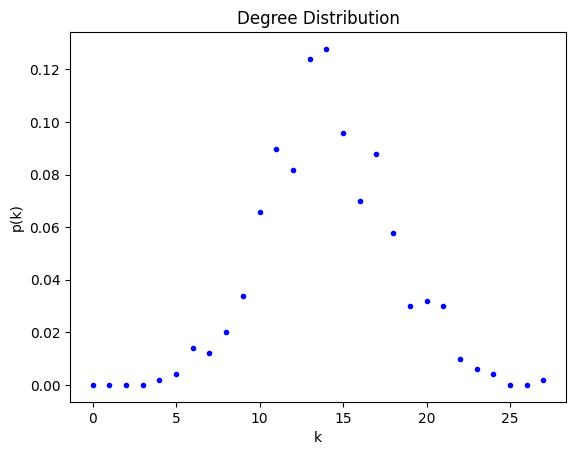

Graph 1:
Average degree is 14.119760479041917
 Maximum degree is for node 419 with degree 27 
SD is 3.6314259229739045
Graph 2:
Average degree is 2.0961538461538463
 Maximum degree is for node 180 with degree 35 
SD is 2.3604075217298925


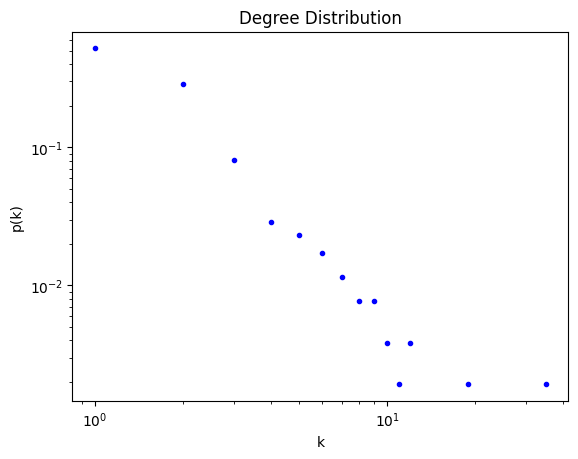

In [1]:
import csv
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G1 = nx.Graph()
with open('Part I/Graph1.csv', newline='') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=';', quotechar='|')
    for row in spamreader:
        G1.add_edge(row[0], row[1])

print(G1)

G2 = nx.Graph()
with open('Part I/Graph2.csv', newline='') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=';', quotechar='|')
    for row in spamreader:
        G2.add_edge(row[0], row[1])

print(G2)

# Source - https://stackoverflow.com/q/53958700
# Posted by Amit Mek, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-31, License - CC BY-SA 4.0

def plot_degree_dist_G1(G):
    degree_hist = nx.degree_histogram(G) 
    degree_hist = np.array(degree_hist, dtype=float)
    degree_prob = degree_hist/G.number_of_nodes()
    plt.plot(np.arange(degree_prob.shape[0]),degree_prob,'b.')
    plt.xlabel('k')
    plt.ylabel('p(k)')
    plt.title('Degree Distribution')

def plot_degree_dist_G2(G):
    degree_hist = nx.degree_histogram(G) 
    degree_hist = np.array(degree_hist, dtype=float)
    degree_prob = degree_hist/G.number_of_nodes()
    plt.loglog(np.arange(degree_prob.shape[0]),degree_prob,'b.')
    plt.xlabel('k')
    # plt.xscale('log')
    # plt.yscale('log')
    # # plt.xticks([1,10,100])
    # # plt.yticks([1,10,100,1000])
    plt.ylabel('p(k)')
    plt.title('Degree Distribution')

plot_degree_dist_G1(G1)
plt.savefig('DegDistG1.png')
plt.show()
plot_degree_dist_G2(G2)
plt.savefig('DegDistG2.png')

# Average degree of an undirected graph k = 2*number of edges/number of nodes
def average_deg(graph):
    k = 2 * float(len(graph.edges)) / float(len(graph.nodes))
    print(f'Average degree is {k}')

def max_degrees(G):
    degrees = [val for (node, val) in G.degree()]
    nodes = [node for (node, val) in G.degree()]
    maximum = max(degrees)
    return (nodes[degrees.index(maximum)], maximum)

def standard_deviation(G) :
    degrees = [val for (node, val) in G.degree()]
    sd = np.std(degrees)
    return (sd)



print("Graph 1:")
average_deg(G1)
print(f' Maximum degree is for node { max_degrees(G1)[0]} with degree { max_degrees(G1)[1]} ')
print(f'SD is {standard_deviation(G1)}')

print("Graph 2:")
average_deg(G2)
print(f' Maximum degree is for node { max_degrees(G2)[0]} with degree { max_degrees(G2)[1]} ')
print(f'SD is {standard_deviation(G2)}')
#standard deviation





(array([36, 98]),)

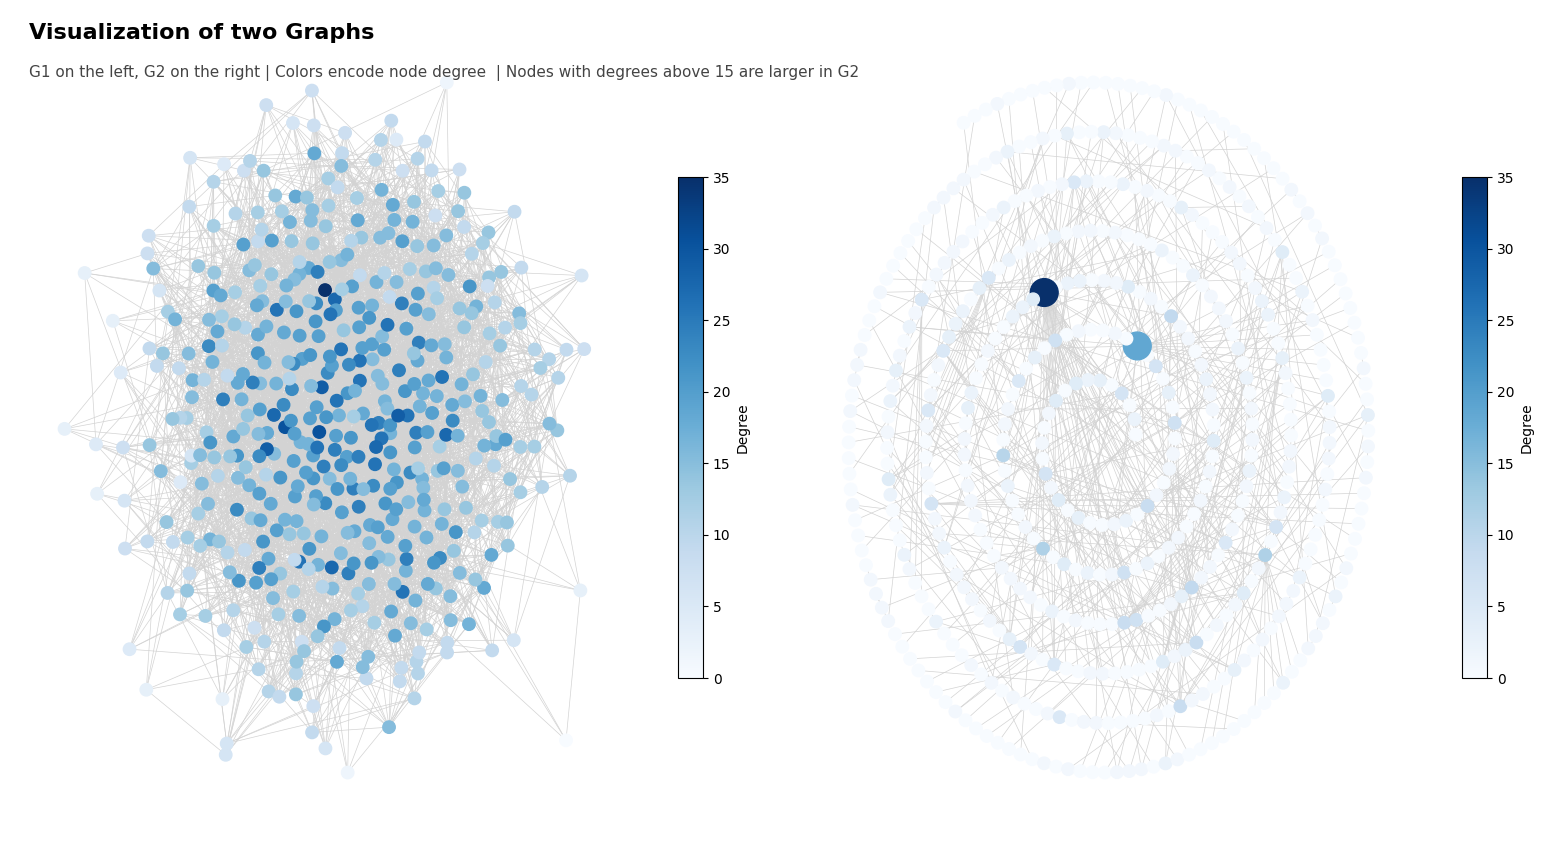

In [2]:
# (b)
## AI Disclosure: All Ideas come from us. Every AI query has been about coding practices and visualizations, speeding up the coding process. 


fig, axes = plt.subplots(1, 2, figsize=(16, 9))

deg1 = (np.array([G1.degree(n) for n in G1.nodes()]))
deg2 = (np.array([G2.degree(n) for n in G2.nodes()]))
node_sizes1 = np.repeat(80,len(deg1))
node_sizes2 = np.repeat(80,len(deg2))

node_sizes2[deg2>15] = 400

print(np.where(deg2>15))

nx.draw(
    G1,
    ax=axes[0],
    with_labels=False,
    node_size=node_sizes1,
    node_color=deg1,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)
sm1 = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                             norm=plt.Normalize(vmin=0, vmax=35))
sm1.set_array([])
fig.colorbar(sm1, ax=axes[0], label='Degree', shrink=0.6)

nx.draw(
    G2,
    ax=axes[1],
    pos = nx.spiral_layout(G2,equidistant =True ),
    with_labels=False,
    node_size=node_sizes2,
    node_color=deg2,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)
sm2 = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                             norm=plt.Normalize(vmin=0, vmax=35))
sm2.set_array([])
fig.colorbar(sm2, ax=axes[1], label='Degree', shrink=0.6)
fig.suptitle("Visualization of two Graphs", fontsize=16, fontweight='bold',y = 0.93, x=0.021, ha='left')

fig.text(0.021, 0.87, "G1 on the left, G2 on the right | Colors encode node degree  | Nodes with degrees above 15 are larger in G2",
         ha='left', fontsize=11, color='#444')
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_58144\4092054466.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.5)


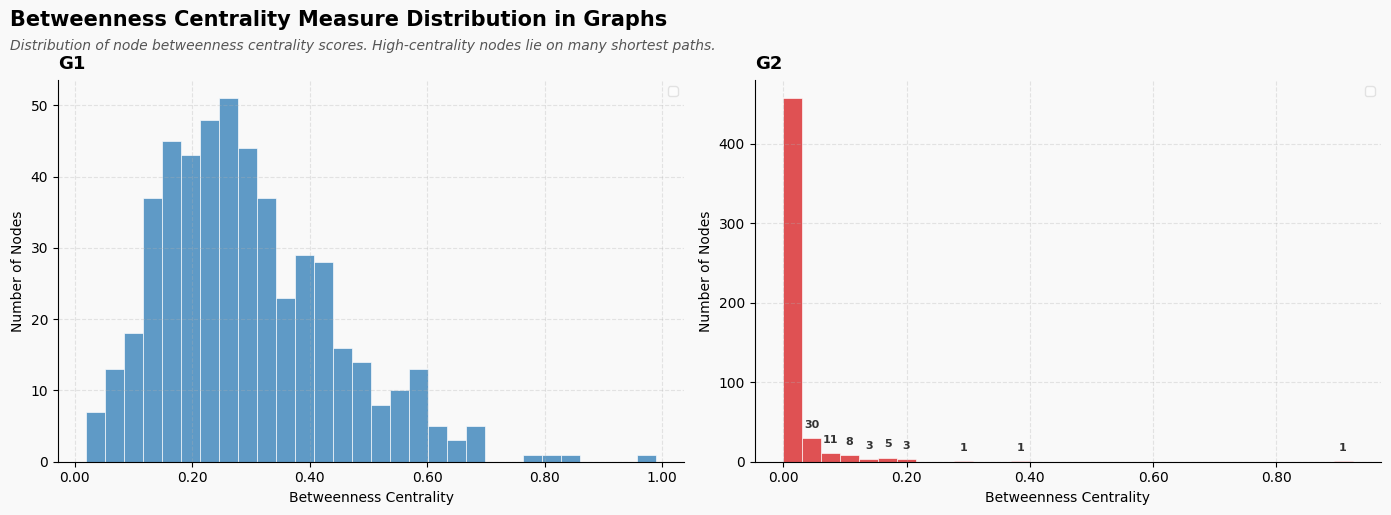

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx


# --- Compute betweenness centrality ---
bc1 = np.array(list(nx.betweenness_centrality(G1).values()))*90
bc2 = np.array(list(nx.betweenness_centrality(G2).values()))/0.8

# --- Style setup ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f9f9f9')

# --- Suptitle + subtitle ---
fig.suptitle("Betweenness Centrality Measure Distribution in Graphs",
             fontsize=15, fontweight='bold', x=0.01, ha='left', y=1.02)
fig.text(0.01, 0.94,
         "Distribution of node betweenness centrality scores. "
         "High-centrality nodes lie on many shortest paths.",
         ha='left', fontsize=10, color='#555555', style='italic')

colors = ['#2c7bb6', '#d7191c']
labels = ['G1', 'G2']

for ax, bc, color, label in zip(axes, [bc1, bc2], colors, labels):
    ax.set_facecolor('#f9f9f9')
    n, bins, patches = ax.hist(bc, bins=30, color=color, alpha=0.75,
                                edgecolor='white', linewidth=0.6)
    if label == 'G2':
        threshold = np.percentile(bc, 80)  # top 20% centrality values
        for count, left_edge, right_edge in zip(n, bins[:-1], bins[1:]):
            if left_edge >= threshold and count > 0:
                bin_center = (left_edge + right_edge) / 2
                ax.annotate(
                    f'{int(count)}',
                    xy=(bin_center, count),
                    xytext=(0, 6),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='#333'
                )

 
    ax.set_title(label, fontsize=13, fontweight='bold', loc='left', pad=8)
    ax.set_xlabel('Betweenness Centrality', fontsize=10)
    ax.set_ylabel('Number of Nodes', fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

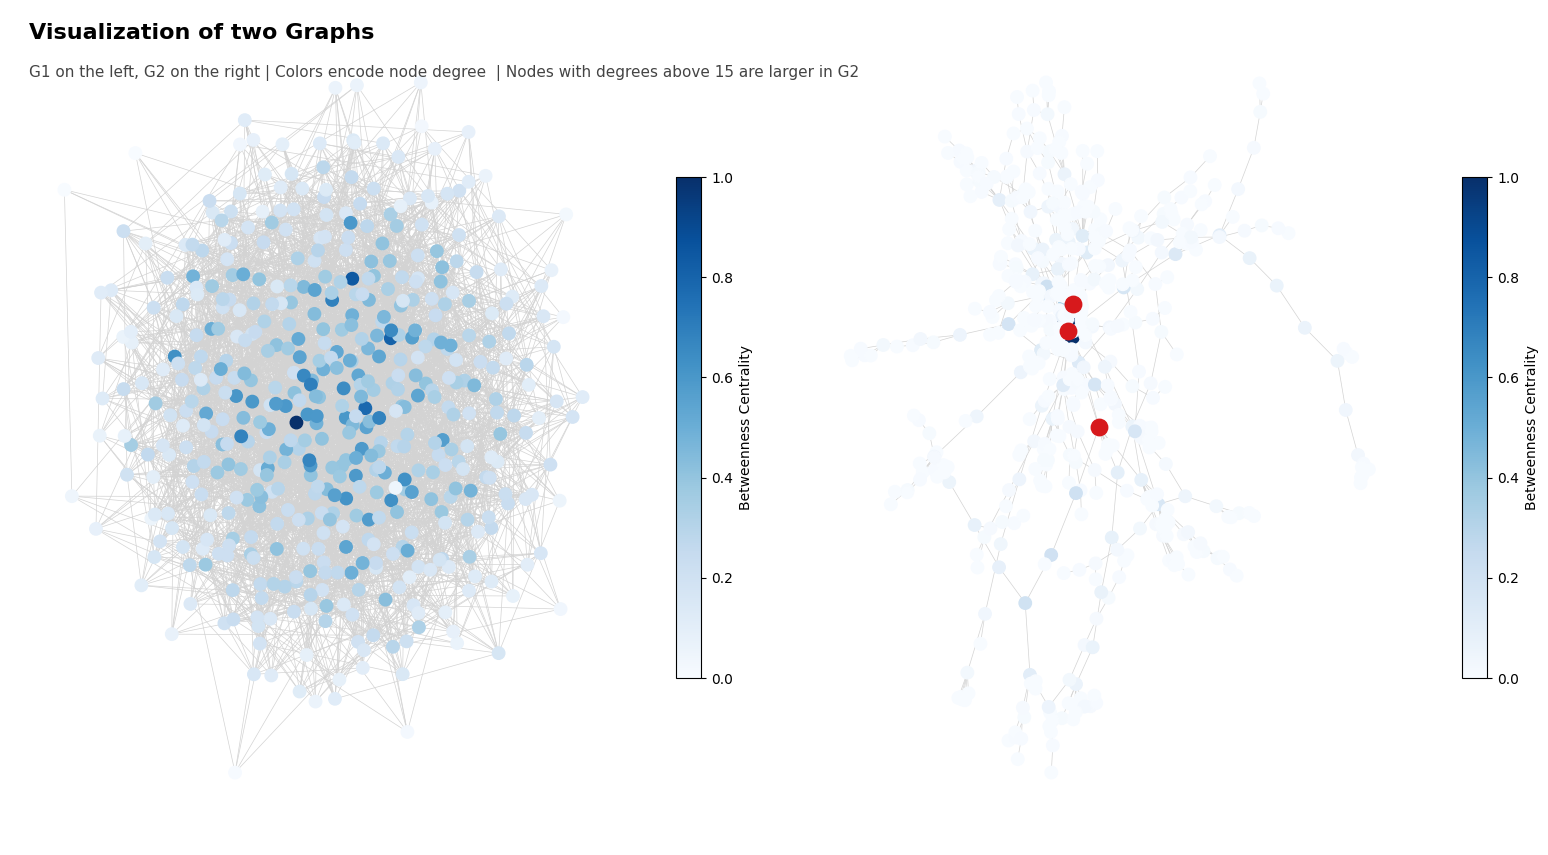

In [4]:
# (b)2)
## AI Disclosure: All Ideas come from us. Every AI query has been about coding practices and visualizations, speeding up the coding process. 
b1 = nx.betweenness_centrality(G1)
betw1 = np.array([b1[n] for n in G1.nodes()])
b2 = nx.betweenness_centrality(G2)


betw2 = np.array([b2[n] for n in G2.nodes()])
c1 = np.percentile(betw1,0.85)
c2 = np.percentile(betw2,0.85)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))


nx.draw(
    G1,
    ax=axes[0],
    with_labels=False,
    node_size=node_sizes1,
    node_color=betw1,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)
sm1 = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm1.set_array([])
fig.colorbar(sm1, ax=axes[0], label='Betweenness Centrality', shrink=0.6)


pos2 = nx.spring_layout(G2, seed=0)
nx.draw(
    G2,
    ax=axes[1],
    pos = pos2,
    with_labels=False,
    node_size=node_sizes2,
    node_color=betw2,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)


nx.draw_networkx_nodes(G2, pos = pos2, nodelist=[n for n in G2.nodes if b2[n]>0.2], 
                       node_size=140, node_color="#d7191c")
sm2 = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[1], label='Betweenness Centrality', shrink=0.6)
fig.suptitle("Visualization of two Graphs", fontsize=16, fontweight='bold',y = 0.93, x=0.021, ha='left')

fig.text(0.021, 0.87, "G1 on the left, G2 on the right | Colors encode node degree  | Nodes with degrees above 15 are larger in G2",
         ha='left', fontsize=11, color='#444')
plt.tight_layout()
plt.show()

We see that the Power Law graph has few nodes with high degree, but many nodes have small degree (represented by light color nodes). Moreover, the betweenness centrality measures also has a power law distribution and approximate normal distribution in the two graphs. 

# Question 2



We try to mimic dynamics of an infection spreading. There are random networks with different connections that we will analyze. We want to see the spread of the virus after a few time stamps, given limited initial exposure. We analyze and compare a binomial random graph with p = 0.002 and a random scale-free graph with parameter $\lambda = 2.5$. 

To run the experiment, for each type of random graph, we select 1 random individuals and consider them infected. Then, we run the experiment for 50 time steps, keeping track of the spread of the virus and proportion of infected population through time. We simulate this experiment with a random graph and random initial infected personel many times to understand the empirical statistical distributions of these two models. We will compare the means and standard deviations of the two models. 

We predict that the model with binomial distribution initially has higher infection rate, as all points have expected 2 edges, with equal probabilities. In scale-free models, as long as we do not reach the nodes with high degrees, the rate of infection is slower. As 50 time stamps is may be insuffiecient for the infection to reach high degree nodes, in many iterations the disease spread is more limited. Overall, eventhough similar final infection proportion is expected for both models, the variance for scale-free model is predicted to be higher. 



In [5]:
import sys
sys.path.insert(0, "Part II")
import engine as eng
import experiments as exp
import visualizer as viz
import csv
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [6]:

N=1000
tMax=50
nExp=1000
infected=1
vaccinated=5
gamma=2.5
probabilityOfTransmission=0.5


#generating a random graph with 1000 nodes
rG=nx.binomial_graph(N,2/N)


#generating a powerlaw graph with 1000 nodes 
plG=exp.generatePowerLawGraph(N,gamma)

repeated_exp_dict_rG = exp.repeatedExperiments(exp.fullyRandomExperiment,rG,tMax,probabilityOfTransmission,1,0, nExp)
average_states_50_rG = exp.averageExperiment(repeated_exp_dict_rG,50)
repeated_exp_dict_plG = exp.repeatedExperiments(exp.fullyRandomExperiment,plG,tMax,probabilityOfTransmission,1,0, nExp)
average_states_50_plG = exp.averageExperiment(repeated_exp_dict_plG,50)
    

Experiment: 0 done.
Experiment: 100 done.
Experiment: 200 done.
Experiment: 300 done.
Experiment: 400 done.
Experiment: 500 done.
Experiment: 600 done.
Experiment: 700 done.
Experiment: 800 done.
Experiment: 900 done.
Experiment: 0 done.
Experiment: 100 done.
Experiment: 200 done.
Experiment: 300 done.
Experiment: 400 done.
Experiment: 500 done.
Experiment: 600 done.
Experiment: 700 done.
Experiment: 800 done.
Experiment: 900 done.


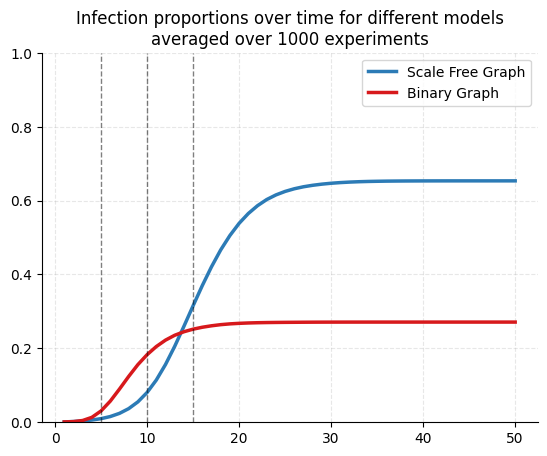

Average infection proportion at t = 5
 --Binary Random Graph:  0.015532%
 --Scale Free Graph:  0.057199%
Average infection proportion at t = 10
 --Binary Random Graph:  0.11421200000000001%
 --Scale Free Graph:  0.20488399999999998%
Average infection proportion at t = 15
 --Binary Random Graph:  0.36987200000000003%
 --Scale Free Graph:  0.25712599999999997%


In [7]:
# Graph of infection in two groups through time

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})


colors = ['#2c7bb6', '#d7191c']
plt.plot( range(1,51), 
          [n/N for _,n,_ in average_states_50_rG],
    color=colors[0],        
    linewidth=2.5,       
    linestyle='-',      
    label='Scale Free Graph',         
)

plt.plot( range(1,51), 
          [n/N for _,n,_ in average_states_50_plG],
    color=colors[1],        
    linewidth=2.5,       
    linestyle='-',      
    label='Binary Graph',         
)

plt.axvline(x=5, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
plt.axvline(x=15, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
plt.axvline(x=10, color='black', linestyle='--', linewidth=1, alpha = 0.5 )


plt.title('Infection proportions over time for different models\naveraged over 1000 experiments')
plt.ylim((0,1))
plt.legend()
plt.show()

for t in [5,10,15]:
    print(f'Average infection proportion at t = {t}')
    print(f' --Binary Random Graph:  {average_states_50_rG[t][1]/1000}%')
    print(f' --Scale Free Graph:  {average_states_50_plG[t][1]/1000}%')


# Question Three: Clustering Coefficient in Random Graphs

Clustering coefficient is average of local transevities of nodes. By considering the connected neighbors of each node over their total possible connections.

$$c_i = \frac{2K[G_i]}{K_i(k_i-1)}$$

$$C = \frac{1}{n}\Sigma_{i=1}^n c_i$$

### Part a) Experiment modeling
 A simple experiment would be a monte carlo simulation. For each probability we create multiple random graphs with fixed random order (Cardinality of nodes) in a prespecified range such that graph is large enough. Then, for each graph, we calculate the clustering coefficient and then average the coefficients out for each of the probabilities. By including proper randomness in the data generation process, we can understand the behavior of clustering coefficient in the model. 

Alternatively, since the each edge in a random binomial graph is independant of other edges, one can create one big graph and consider the average clustering coefficient in the large graph, as average of local clustering coefficients in the large graph are in practice the same as averaging clustering coefficients of multiple smaller graphs. We choose this latter approach with graph order of 1000

### Part b) Interpretation and expectation:

We observe a empricial linear realtion between clustering coefficient and probability in random binomial graphs. 
As probability of edge being in graph is the same for all possible edges and they are independent, the subgraphs (Created of neighbors of each node) must have random binomial probability as well. Then for a node with K neighbors, expected clustering coefficient is:
$$E[\text{Clustering Coefficient}_i|k_i] = \frac{2E[K[G_i]]}{k_i(k_i-1)} = \frac{2\frac{k_i(k_i-1)}{2}\cdot p}{k_i(k_i-1)} = p$$

since
 $$Pr(K[G_i] = k) = {\frac{k_i(k_i-1)}{2} \choose k} p^k (1-p)^{\frac{k_i(k_i-1)}{2}-k}$$

$$E_{ki}[\text{Clustering Coefficient}_i] = E_{ki}[E[\text{Clustering Coefficient}_i|k_i]] = p$$ 

$$ E[\text{Average Clustering Coefficient}] = \frac{1}{n}\Sigma_{i=1}^n E_{ki}[\text{Clustering Coefficient}_i] = \frac{1}{n}\Sigma_{i=1}^n p = p$$

So similar to empirical results, expectation of clustering coefficient is same as probability p. 



In [8]:
# Part c) 
import scipy.stats as stats
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Order of the graph: n (numebr of nodes)
n = 1000
#Possible p values
probabilities = np.geomspace(0.01,1,15,endpoint = False) # We analyze geom spaces between 0 and 1, since we expected the most interesting effects happen in smaller p, if anywhere
Clustering_coeffs = []

for p in probabilities:
    G = nx.gnp_random_graph(n, p, seed = 0)
    coef = nx.average_clustering(G)
    Clustering_coeffs.append(coef)
    print(f'p is {p} is done')



    


p is 0.01 is done
p is 0.013593563908785255 is done
p is 0.018478497974222907 is done
p is 0.025118864315095794 is done
p is 0.034145488738336005 is done
p is 0.046415888336127774 is done
p is 0.06309573444801933 is done
p is 0.08576958985908942 is done
p is 0.11659144011798317 is done
p is 0.15848931924611134 is done
p is 0.21544346900318834 is done
p is 0.29286445646252357 is done
p is 0.3981071705534973 is done
p is 0.5411695265464638 is done
p is 0.7356422544596414 is done


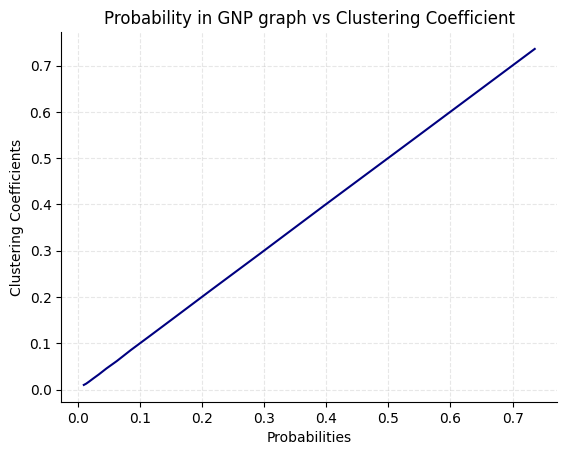

In [9]:
import matplotlib.pyplot as plt
plt.plot(probabilities,Clustering_coeffs, color = 'navy')
plt.xlabel('Probabilities')
plt.ylabel('Clustering Coefficients')

plt.title("Probability in GNP graph vs Clustering Coefficient")
plt.show()